In [1]:
# ============================================
# 통계 분석 - 챕터2-1 ③
# 목적: 유동인구 급증 시 1인당 매출(객단가) 오히려 하락하는지 검증
# 방법: 피어슨 상관계수 (유동인구 변화율 × 객단가 변화율)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 추정매출 로드
import glob
매출_파일들 = glob.glob('../data/03_추정매출/*.csv')
매출_리스트 = []
for 파일 in 매출_파일들:
    if '2025' in 파일:
        continue
    df = pd.read_csv(파일, encoding='cp949', low_memory=False)
    매출_리스트.append(df)
sales = pd.concat(매출_리스트, ignore_index=True)

# 길단위인구 로드
floating = pd.read_csv(
    '../data/05_길단위인구/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='cp949'
)

# 분석 기간 필터링
sales = sales[sales['기준_년분기_코드'] < 20250]
floating = floating[floating['기준_년분기_코드'] < 20250]

print(f'추정매출: {sales.shape}')
print(f'길단위인구: {floating.shape}')

추정매출: (434199, 62)
길단위인구: (39589, 27)


In [2]:
# ============================================
# 관광특구 한정 필터링 + 상권별 집계
# ============================================

# 상권별 분기별 집계
sales_agg = sales[sales['상권_구분_코드_명'] == '관광특구'].groupby(
    ['기준_년분기_코드', '상권_코드']
).agg(
    당월_매출=('당월_매출_금액', 'sum'),
    당월_건수=('당월_매출_건수', 'sum')
).reset_index()

# 객단가 계산
sales_agg['객단가'] = sales_agg['당월_매출'] / sales_agg['당월_건수'].replace(0, np.nan)

# 유동인구 병합
floating_agg = floating.groupby(
    ['기준_년분기_코드', '상권_코드']
)['총_유동인구_수'].sum().reset_index()

df = sales_agg.merge(floating_agg, on=['기준_년분기_코드', '상권_코드'], how='inner')

print(f'병합 완료: {df.shape}')
print(df.head(3))

병합 완료: (120, 6)
   기준_년분기_코드    상권_코드         당월_매출      당월_건수           객단가  총_유동인구_수
0    20201.0  3001491  7.450278e+10  3115589.0  23912.902625   2060066
1    20201.0  3001492  2.582203e+11  8880113.0  29078.498140   6665830
2    20201.0  3001493  8.595231e+10  2693971.0  31905.434371   3269620


In [3]:
# ============================================
# 상권별 유동인구 변화율 × 객단가 변화율 계산
# 목적: 유동인구가 급증하는 구간에 객단가가 하락하는지 확인
# ============================================

# 분기별 정렬
df = df.sort_values(['상권_코드', '기준_년분기_코드'])

# 상권별 전분기 대비 변화율 계산
df['유동인구_변화율'] = df.groupby('상권_코드')['총_유동인구_수'].pct_change() * 100
df['객단가_변화율'] = df.groupby('상권_코드')['객단가'].pct_change() * 100

# 결측치 제거
df_clean = df.dropna(subset=['유동인구_변화율', '객단가_변화율'])

print(f'분석 대상: {df_clean.shape[0]}개 구간')
print()
print('유동인구 변화율 기술통계:')
print(df_clean['유동인구_변화율'].describe().round(2))
print()
print('객단가 변화율 기술통계:')
print(df_clean['객단가_변화율'].describe().round(2))

분석 대상: 114개 구간

유동인구 변화율 기술통계:
count    114.00
mean       0.65
std        7.02
min      -17.47
25%       -3.99
50%       -1.14
75%        5.00
max       21.63
Name: 유동인구_변화율, dtype: float64

객단가 변화율 기술통계:
count    114.00
mean       0.35
std       11.45
min      -43.63
25%       -6.34
50%       -0.71
75%        7.35
max       48.80
Name: 객단가_변화율, dtype: float64


In [6]:
# ============================================
# 피어슨 상관계수 계산
# 유동인구 변화율 × 객단가 변화율
# ============================================

# 전체 상관계수
corr, pvalue = stats.pearsonr(
    df_clean['유동인구_변화율'],
    df_clean['객단가_변화율']
)

print('관광특구 유동인구 변화율 × 객단가 변화율 피어슨 상관계수')
print('=' * 50)
print(f'상관계수: {corr:.3f}')
print(f'p-value:  {pvalue:.4f}')
print()

# p-value 해석
if pvalue < 0.05:
    print('통계적으로 유의미 (p < 0.05)')
else:
    print('통계적으로 유의미하지 않음 (p >= 0.05)')

print()

# 상관계수 방향 해석
if corr < 0:
    print('→ 유동인구 증가할수록 객단가 하락하는 패턴 존재')
elif corr > 0:
    print('→ 유동인구 증가할수록 객단가도 상승하는 패턴')
else:
    print('→ 유동인구와 객단가 변화 간 관계 없음')

관광특구 유동인구 변화율 × 객단가 변화율 피어슨 상관계수
상관계수: 0.194
p-value:  0.0386

통계적으로 유의미 (p < 0.05)

→ 유동인구 증가할수록 객단가도 상승하는 패턴


In [8]:
# ============================================
# 유동인구 급증 구간만 필터링
# 유동인구 변화율 상위 25% (5% 이상 증가) 구간
# ============================================

# 급증 구간 필터링
급증_구간 = df_clean[df_clean['유동인구_변화율'] >= 5.0]

print(f'급증 구간 수: {len(급증_구간)}개')
print(f'전체 대비 비중: {len(급증_구간)/len(df_clean)*100:.1f}%')
print()

# 급증 구간 피어슨 상관계수
corr_급증, pvalue_급증 = stats.pearsonr(
    급증_구간['유동인구_변화율'],
    급증_구간['객단가_변화율']
)

print('유동인구 급증 구간 피어슨 상관계수')
print('=' * 50)
print(f'상관계수: {corr_급증:.3f}')
print(f'p-value:  {pvalue_급증:.4f}')
print()

if pvalue_급증 < 0.05:
    print('통계적으로 유의미 (p < 0.05)')
else:
    print('통계적으로 유의미하지 않음 (p >= 0.05)')

print()
if corr_급증 < 0:
    print('→ 유동인구 급증 시 객단가 하락 패턴 확인 ')
else:
    print('→ 유동인구 급증 시에도 객단가 하락 패턴 없음')

# 급증 구간 기술통계
print()
print('급증 구간 객단가 변화율:')
print(급증_구간['객단가_변화율'].describe().round(2))

급증 구간 수: 29개
전체 대비 비중: 25.4%

유동인구 급증 구간 피어슨 상관계수
상관계수: -0.178
p-value:  0.3552

통계적으로 유의미하지 않음 (p >= 0.05)

→ 유동인구 급증 시 객단가 하락 패턴 확인 

급증 구간 객단가 변화율:
count    29.00
mean      3.36
std       9.37
min     -11.00
25%      -3.84
50%       0.60
75%      11.73
max      24.16
Name: 객단가_변화율, dtype: float64


In [9]:
# ============================================
# 챕터2-3 ⑦ 회귀분석 - 매출 결정 요인 변수 중요도
# 목적: 직장인구·상주인구·유동인구·역세권 중 매출 예측 변수 중요도 도출
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# 직장인구 로드
df_직장 = pd.read_csv(
    '../data/06_직장인구/서울시 상권분석서비스(직장인구-상권).csv',
    encoding='cp949'
)

# 상주인구 로드
df_상주 = pd.read_csv(
    '../data/07_상주인구/서울시 상권분석서비스(상주인구-상권).csv',
    encoding='cp949'
)

print(f'직장인구: {df_직장.shape}')
print(f'상주인구: {df_상주.shape}')

직장인구: (45840, 26)
상주인구: (40812, 29)


In [10]:
# ============================================
# 데이터 병합
# ============================================

# 추정매출 상권별 집계 (전체 상권 유형)
sales_reg = sales.groupby(
    ['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']
).agg(
    당월_매출=('당월_매출_금액', 'sum'),
    당월_건수=('당월_매출_건수', 'sum')
).reset_index()

sales_reg['객단가'] = sales_reg['당월_매출'] / sales_reg['당월_건수'].replace(0, np.nan)

# 유동인구 병합
sales_reg = sales_reg.merge(
    floating[['기준_년분기_코드', '상권_코드', '총_유동인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
)

# 직장인구 병합
sales_reg = sales_reg.merge(
    df_직장[['기준_년분기_코드', '상권_코드', '총_직장_인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
)

# 상주인구 병합
sales_reg = sales_reg.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '총_상주인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='left'
)

# 역세권 여부 병합 (아까 만든 gdf_상권_m에서)
역세권_df = pd.read_csv('../data/외부데이터/서울교통공사_1_8호선 역사 좌표(위경도) 정보_20250814.csv', encoding='cp949')

print(f'병합 완료: {sales_reg.shape}')
print(sales_reg.isnull().sum())

병합 완료: (31382, 9)
기준_년분기_코드       0
상권_코드           0
상권_구분_코드_명      0
당월_매출           0
당월_건수           0
객단가             0
총_유동인구_수       11
총_직장_인구_수     173
총_상주인구_수      312
dtype: int64


In [14]:
# ============================================
# 챕터2-3 ⑦ - 매출 결정 요인 변수별 피어슨 상관계수
# 목적: 유동인구·직장인구·상주인구 중 매출과 가장 강한 변수 확인
# ============================================

from scipy import stats

변수_컬럼 = ['총_유동인구_수', '총_직장_인구_수', '총_상주인구_수']
변수_라벨 = ['유동인구', '직장인구', '상주인구']
상권_유형 = ['관광특구', '발달상권', '골목상권', '전통시장']

# 결측치 제거
df_reg = sales_reg[변수_컬럼 + ['당월_매출', '상권_구분_코드_명']].dropna()

print('상권 유형별 매출 결정 요인 피어슨 상관계수')
print('=' * 55)

for 유형 in 상권_유형:
    sub = df_reg[df_reg['상권_구분_코드_명'] == 유형]
    print(f'\n{유형}')
    for 변수, 라벨 in zip(변수_컬럼, 변수_라벨):
        corr, pvalue = stats.pearsonr(sub[변수], sub['당월_매출'])
        유의 = '유의미' if pvalue < 0.05 else '유의미하지않음'
        print(f'  {라벨:<8} x 매출: {corr:.3f}  ({유의})')

상권 유형별 매출 결정 요인 피어슨 상관계수

관광특구
  유동인구     x 매출: 0.605  (유의미)
  직장인구     x 매출: 0.776  (유의미)
  상주인구     x 매출: -0.111  (유의미하지않음)

발달상권
  유동인구     x 매출: 0.285  (유의미)
  직장인구     x 매출: 0.336  (유의미)
  상주인구     x 매출: 0.133  (유의미)

골목상권
  유동인구     x 매출: 0.443  (유의미)
  직장인구     x 매출: 0.413  (유의미)
  상주인구     x 매출: 0.442  (유의미)

전통시장
  유동인구     x 매출: 0.295  (유의미)
  직장인구     x 매출: 0.307  (유의미)
  상주인구     x 매출: 0.108  (유의미)


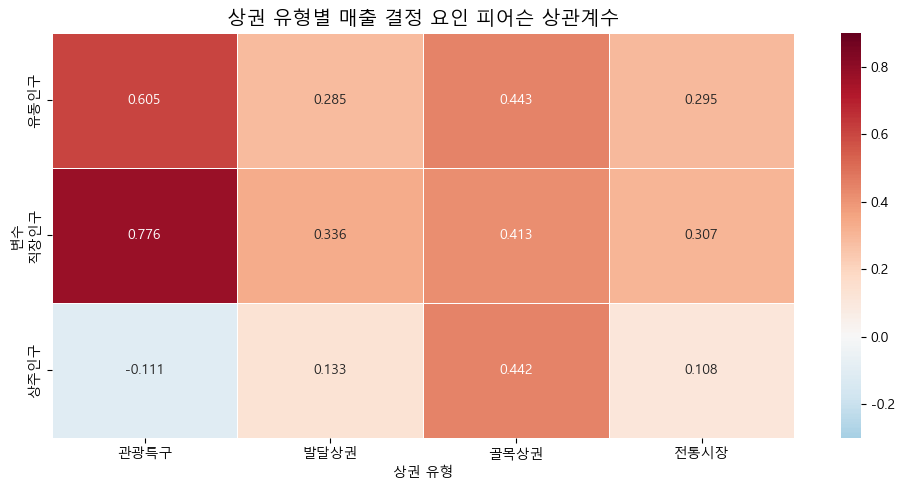

In [15]:
# ============================================
# 상권 유형별 매출 결정 요인 상관계수 히트맵
# ============================================

# 데이터 정리
결과_data = {
    '관광특구': [0.605, 0.776, -0.111],
    '발달상권': [0.285, 0.336, 0.133],
    '골목상권': [0.443, 0.413, 0.442],
    '전통시장': [0.295, 0.307, 0.108]
}

df_결과 = pd.DataFrame(결과_data, index=['유동인구', '직장인구', '상주인구'])

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    df_결과,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    vmin=-0.3,
    vmax=0.9,
    linewidths=0.5,
    ax=ax
)

ax.set_title('상권 유형별 매출 결정 요인 피어슨 상관계수', fontsize=14)
ax.set_xlabel('상권 유형')
ax.set_ylabel('변수')

plt.tight_layout()
plt.show()